<a href="https://colab.research.google.com/github/NyasaShaiju/Task5-Decision_Trees_and_Random_Forests/blob/main/Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task5- Decision Trees and Random Forests

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0     

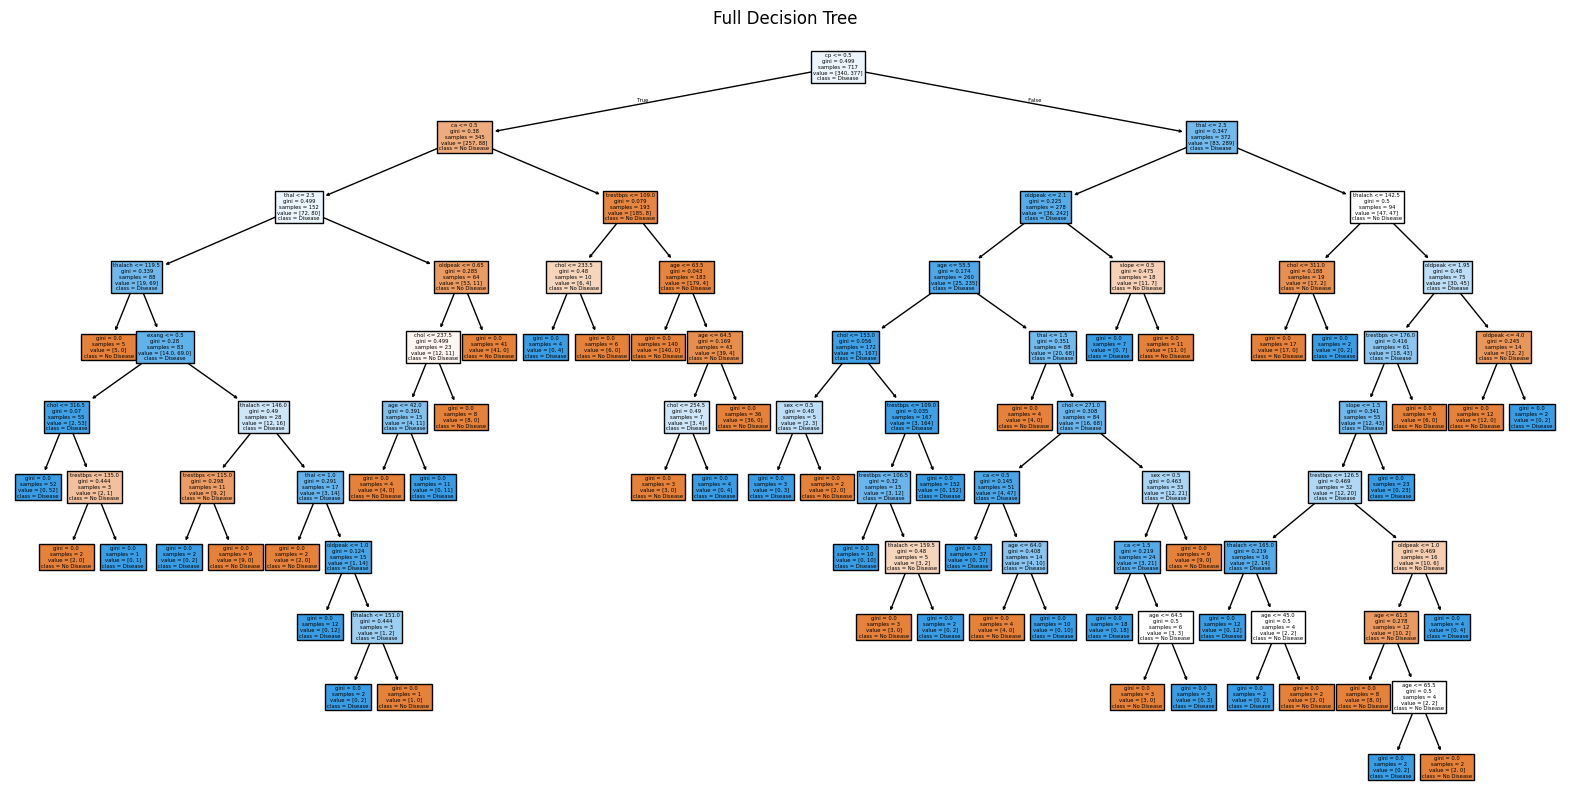

Decision Tree Accuracy - Train: 1.00, Test: 0.97
Pruned Tree Accuracy - Train: 0.90, Test: 0.83
Random Forest Accuracy - Train: 1.00, Test: 0.98


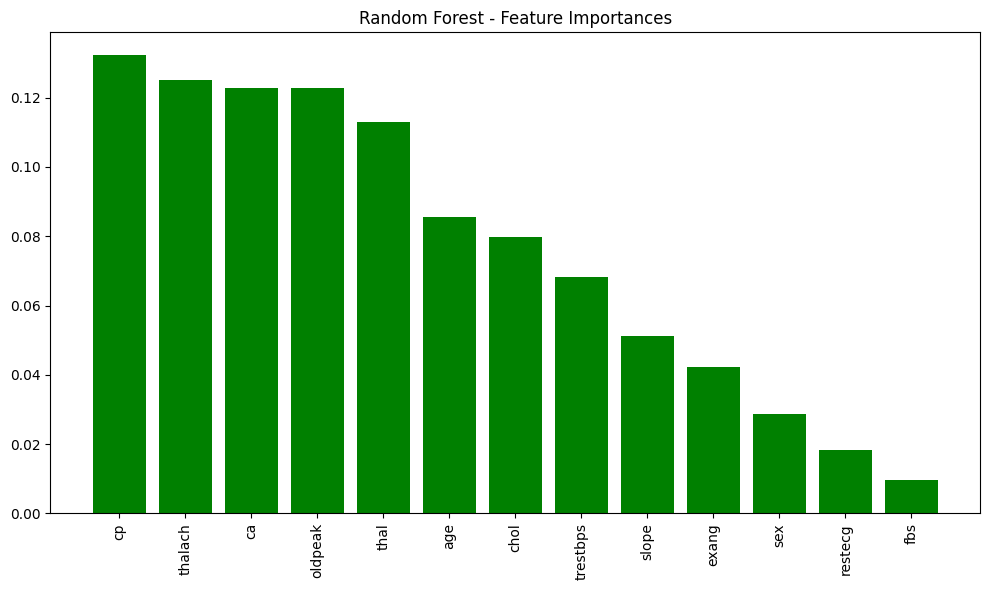

Decision Tree CV Accuracy (mean): 0.83
Random Forest CV Accuracy (mean): 1.00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv('/content/heart.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)


plt.figure(figsize=(20, 10))
plot_tree(dt_clf, filled=True, feature_names=X.columns, class_names=["No Disease", "Disease"])
plt.title("Full Decision Tree")
plt.show()

dt_train_acc = dt_clf.score(X_train, y_train)
dt_test_acc = dt_clf.score(X_test, y_test)
print(f"Decision Tree Accuracy - Train: {dt_train_acc:.2f}, Test: {dt_test_acc:.2f}")


dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)


pruned_train_acc = dt_pruned.score(X_train, y_train)
pruned_test_acc = dt_pruned.score(X_test, y_test)
print(f"Pruned Tree Accuracy - Train: {pruned_train_acc:.2f}, Test: {pruned_test_acc:.2f}")


rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

rf_train_acc = rf_clf.score(X_train, y_train)
rf_test_acc = rf_clf.score(X_test, y_test)
print(f"Random Forest Accuracy - Train: {rf_train_acc:.2f}, Test: {rf_test_acc:.2f}")


importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest - Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], color='green', align='center')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


dt_cv_scores = cross_val_score(dt_pruned, X, y, cv=5)
rf_cv_scores = cross_val_score(rf_clf, X, y, cv=5)

print(f"Decision Tree CV Accuracy (mean): {dt_cv_scores.mean():.2f}")
print(f"Random Forest CV Accuracy (mean): {rf_cv_scores.mean():.2f}")
